Accuracy: 0.7037037037037037


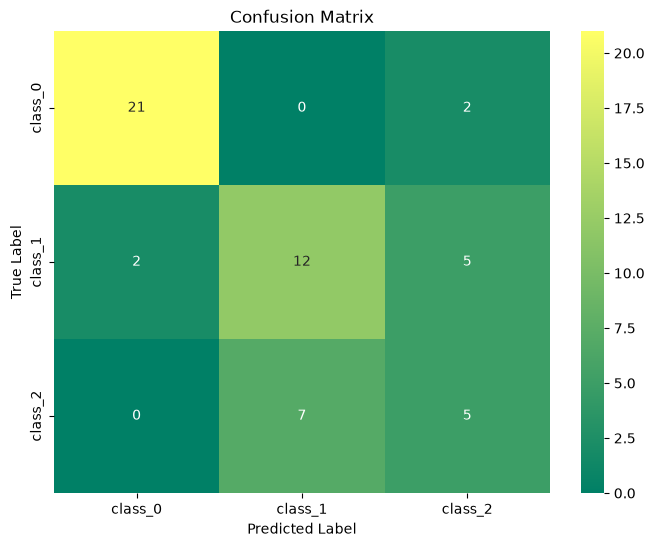

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


# Load Wine dataset
wine = load_wine()

data = pd.DataFrame(
    data=wine.data,
    columns=wine.feature_names
)

data['Target'] = wine.target


# Separate input and output
X = data.drop('Target', axis=1)
y = data['Target']


# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=1
)


# Create KNN model
model = KNeighborsClassifier(n_neighbors=5)

# Train model
model.fit(X_train, y_train)


# Make predictions
y_pred = model.predict(X_test)


# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='summer',
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()